# Social Network Ads Purchase Prediction

This project builds a Logistic Regression model to predict whether a user will purchase a product based on:

- Age
- Estimated Salary
- Gender

Dataset: Social Network Ads Dataset

Goal: Predict customer purchase behavior using machine learning.

## Dataset Description

Columns:
- User ID – Unique user identifier
- Gender – Male/Female
- Age – Age of user
- EstimatedSalary – User salary
- Purchased – Target variable (0 = No, 1 = Yes)

## Importing Libraries

In [40]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score,confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [41]:
df = pd.read_csv('Social_Network_Ads.csv')

## EDA

In [42]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [43]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [44]:
df.shape

(400, 5)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [46]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

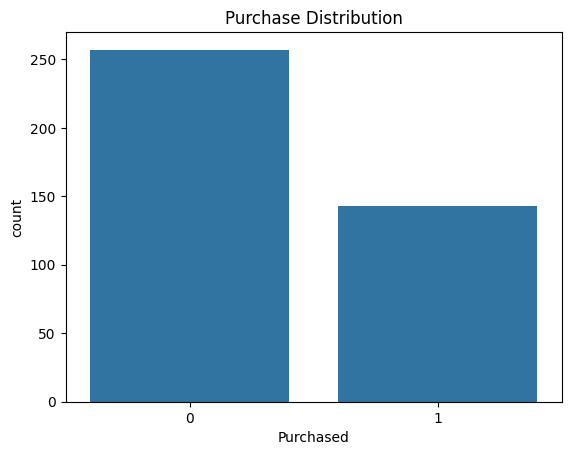

In [47]:
sns.countplot(x='Purchased', data=df)
plt.title("Purchase Distribution")
plt.show()

## Feature Engineering

In [48]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [49]:
df = df.drop('User ID', axis=1)

In [50]:
y = df.Purchased
df = df.drop('Purchased',axis=1)

In [51]:
x = df

In [52]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

## Model Training

**Model Selection**

Logistic Regression is used because:

- Target variable is binary (Purchased or Not Purchased)
- Model is interpretable
- Works well for classification problems

In [53]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [54]:
model = LogisticRegression()

In [55]:
model.fit(x_train,y_train)

LogisticRegression()

## Model Prediction

In [56]:
y_pred = model.predict(x_test)

## Model Evaluation

In [57]:
model.score(x_test,y_test)

0.775

In [58]:
f1_score(y_test,y_pred)

0.6538461538461539

In [60]:
print(confusion_matrix(y_test,y_pred))

[[45  4]
 [14 17]]


## Conclusion

The model successfully predicts purchase behavior using logistic regression.
Age and Estimated Salary show strong influence on purchasing decisions.